In [2]:
# Montamos Google Drive para poder acceder a los archivos del curso
from google.colab import drive
drive.mount('/content/drive')

# Ejecutamos la Tarea 1 completa para heredar todas sus variables:
# youtube_full, youtube_clean, spark, etc.
# Así no duplicamos código y mantenemos un solo punto de verdad para la carga de datos
%run "/content/drive/MyDrive/Colab Notebooks/Big_Data/BigData_Tarea1.ipynb"

Mounted at /content/drive
+---+
| id|
+---+
|  0|
|  1|
|  2|
|  3|
|  4|
+---+

Tabla unificada creada: youtube_full
+-----------+-----------+-------------+--------------------+--------------------+--------------------+--------------------+-------+------+--------+-------------+--------------------+-----------------+----------------+----------------------+--------------------+--------------+-------+
|category_id|   video_id|trending_date|               title|       channel_title|        publish_time|                tags|  views| likes|dislikes|comment_count|      thumbnail_link|comments_disabled|ratings_disabled|video_error_or_removed|         description| category_name|country|
+-----------+-----------+-------------+--------------------+--------------------+--------------------+--------------------+-------+------+--------+-------------+--------------------+-----------------+----------------+----------------------+--------------------+--------------+-------+
|         22|2kyS6SvSYSE|  

In [3]:
# ── PySpark: motor de procesamiento distribuido ──────────────────────────────
import pyspark.sql.functions as F          # Funciones SQL de PySpark (avg, col, count, etc.)
from pyspark.ml.feature import VectorAssembler, StandardScaler
# VectorAssembler: combina múltiples columnas en un solo vector (requerido por MLlib)
# StandardScaler: normaliza los datos para que todas las variables tengan el mismo peso

from pyspark.ml.clustering import KMeans   # Algoritmo de clustering no supervisado
from pyspark.ml.evaluation import ClusteringEvaluator  # Para medir calidad del clustering

# ── Visualización y análisis ─────────────────────────────────────────────────
import matplotlib.pyplot as plt            # Librería base para crear gráficas
import matplotlib.ticker as mticker        # Para formatear los ejes (ej: comas en miles)
import seaborn as sns                      # Gráficas estadísticas con mejor estética
import pandas as pd                        # Necesario para convertir datos de Spark a visualización
import numpy as np                         # Operaciones numéricas

# Establecemos el estilo global de todas las gráficas del notebook
sns.set(style="whitegrid")

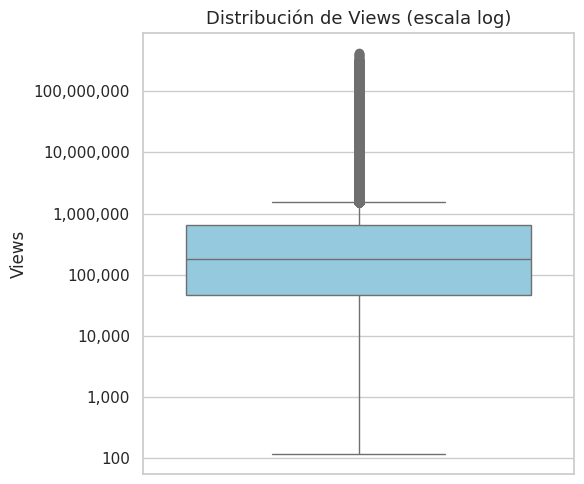

In [4]:
# ── DISTRIBUCIÓN DE VIEWS ────────────────────────────────────────────────────
# Filtramos videos con views > 0 para evitar distorsión por registros vacíos
# Solo seleccionamos la columna que necesitamos antes de convertir a Pandas
# (convertir todo el DataFrame sería muy costoso en memoria)
views_df = youtube_clean.filter(F.col("views") > 0) \
    .select("views").toPandas()

fig, ax = plt.subplots(figsize=(6, 5))

sns.boxplot(y=views_df["views"], color="skyblue", ax=ax)

# Escala logarítmica en el eje Y: INDISPENSABLE para datos de YouTube
# Las views van de cientos a cientos de millones → sin log, la caja
# queda aplastada en el fondo y los outliers dominan visualmente toda la gráfica
ax.set_yscale("log")

# Formateamos el eje Y para mostrar números con comas (1,000,000 en vez de 1e6)
# lambda recibe el valor (x) y su posición (_) y devuelve el string formateado
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

ax.set_title("Distribución de Views (escala log)", fontsize=13)
ax.set_ylabel("Views")
plt.tight_layout()
plt.show()

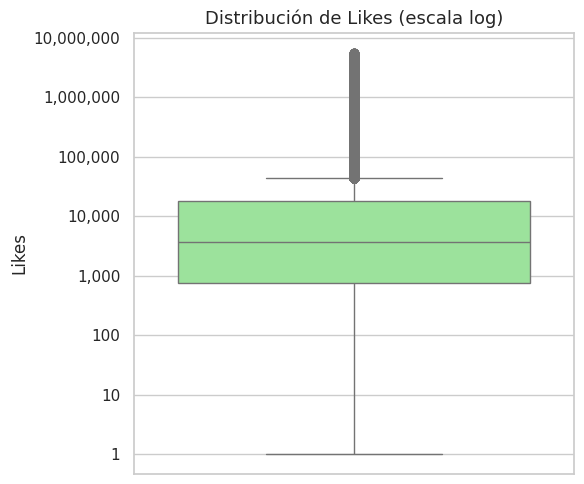

In [5]:
# ── DISTRIBUCIÓN DE LIKES ────────────────────────────────────────────────────
# Mismo criterio que Views: filtramos ceros y usamos escala log
# ya que los likes también siguen una distribución muy sesgada a la derecha
likes_df = youtube_clean.filter(F.col("likes") > 0) \
    .select("likes").toPandas()

fig, ax = plt.subplots(figsize=(6, 5))
sns.boxplot(y=likes_df["likes"], color="lightgreen", ax=ax)

ax.set_yscale("log")  # Necesario: sin esto, la mayoría de videos con pocos likes
                      # quedan invisibles frente a los videos virales

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.set_title("Distribución de Likes (escala log)", fontsize=13)
ax.set_ylabel("Likes")
plt.tight_layout()
plt.show()

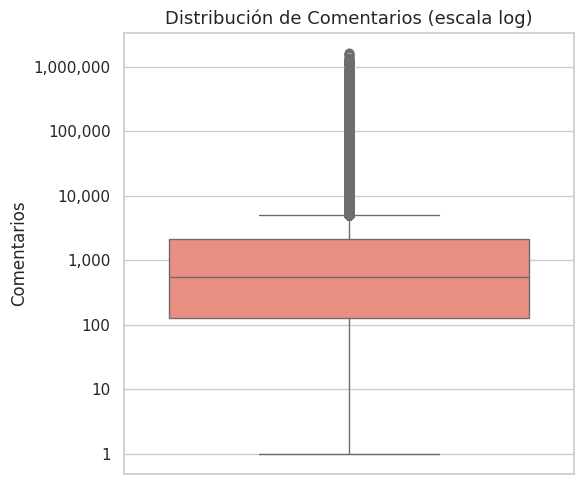

In [6]:
# ── DISTRIBUCIÓN DE COMENTARIOS ──────────────────────────────────────────────
# Filtramos comment_count = 0 porque algunos videos tienen comentarios desactivados
# y esos ceros no representan baja interacción, sino una decisión del creador
comments_df = youtube_clean.filter(F.col("comment_count") > 0) \
    .select("comment_count").toPandas()

fig, ax = plt.subplots(figsize=(6, 5))
sns.boxplot(y=comments_df["comment_count"], color="salmon", ax=ax)

ax.set_yscale("log")  # Escala log: los comentarios también tienen distribución de ley de potencia

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.set_title("Distribución de Comentarios (escala log)", fontsize=13)
ax.set_ylabel("Comentarios")
plt.tight_layout()
plt.show()

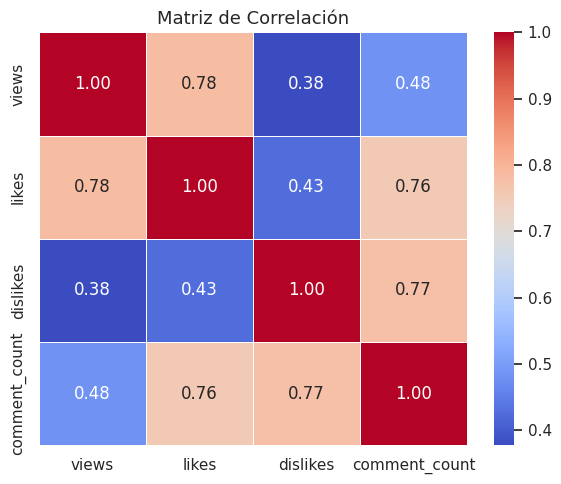

In [7]:
# ── CORRELACIÓN ENTRE VARIABLES NUMÉRICAS ────────────────────────────────────
# Tomamos una muestra del 10% del dataset para no saturar la memoria al convertir a Pandas
# seed=42 garantiza que la muestra sea reproducible en ejecuciones futuras
corr_sample = youtube_clean.select(
    "views", "likes", "dislikes", "comment_count"
).sample(fraction=0.1, seed=42).toPandas()

# .corr() calcula el coeficiente de correlación de Pearson entre cada par de columnas
# Valores cercanos a 1: correlación positiva fuerte
# Valores cercanos a -1: correlación negativa fuerte
# Valores cercanos a 0: sin correlación lineal
corr_matrix = corr_sample.corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    corr_matrix,
    annot=True,       # Muestra el valor numérico dentro de cada celda
    fmt=".2f",        # Formato de 2 decimales para los valores
    cmap="coolwarm",  # Azul = correlación negativa, Rojo = correlación positiva
    linewidths=0.5,   # Líneas entre celdas para mejor legibilidad
    ax=ax
)
ax.set_title("Matriz de Correlación", fontsize=13)
plt.tight_layout()
plt.show()

In [8]:
# ── MÉTRICA DE ENGAGEMENT ────────────────────────────────────────────────────
# El engagement mide qué tan activa es la audiencia relativo a las vistas.
# Un video con 1M views y 100K likes tiene más engagement que uno con 100M views y 50K likes.

youtube_ml = youtube_clean \
    .withColumn(
        "engagement",
        # Engagement total: suma todas las interacciones (positivas y negativas)
        # divididas entre las vistas. Representa el % de audiencia que interactuó.
        (F.col("likes") + F.col("comment_count") + F.col("dislikes")) / F.col("views")
    ) \
    .withColumn(
        "engagement_positive",
        # Engagement positivo: solo likes + comentarios (excluye dislikes)
        # Útil para medir el sentimiento favorable de la audiencia
        (F.col("likes") + F.col("comment_count")) / F.col("views")
    ) \
    .filter(
        # Filtramos videos sin vistas para evitar división entre cero
        # y registros donde el engagement no se pudo calcular
        (F.col("views") > 0) &
        (F.col("engagement").isNotNull())
    )

# Verificamos que las columnas se crearon correctamente
youtube_ml.select("views", "likes", "comment_count", "engagement", "engagement_positive").show(5)

+-------+------+-------------+--------------------+--------------------+
|  views| likes|comment_count|          engagement| engagement_positive|
+-------+------+-------------+--------------------+--------------------+
| 748374| 57527|        15954|  0.1021507962596242| 0.09818753724741908|
|2418783| 97185|        12703| 0.04797205867578861|0.045431111430831124|
|3191434|146033|         8181|   0.049994140565025| 0.04832122487884757|
| 343168| 10172|         2146|0.037835695635956734| 0.03589495524058187|
|2095731|132235|        17518| 0.07240528483855992| 0.07145621265324605|
+-------+------+-------------+--------------------+--------------------+
only showing top 5 rows


In [35]:
# ── PREPARACIÓN DE FEATURES PARA KMEANS ─────────────────────────────────────
# KMeans calcula distancias euclidianas entre puntos.
# Si no escalamos, "views" (que puede ser 200 millones) domina completamente
# sobre "comment_count" (que puede ser 1,000), haciendo que likes, dislikes
# y comentarios sean irrelevantes para el algoritmo.
# Solución: StandardScaler transforma cada variable a media=0 y desviación estándar=1

features = ["views", "likes", "dislikes", "comment_count","engagement"]  # Variables que usará el modelo

# Paso 1: VectorAssembler combina las 4 columnas en un solo vector por fila
# MLlib requiere que todas las features estén en una sola columna de tipo Vector
assembler = VectorAssembler(inputCols=features, outputCol="features_raw")
youtube_ml = assembler.transform(youtube_ml)

# Paso 2: StandardScaler estandariza el vector de features
# withMean=True: centra los datos restando la media
# withStd=True: escala dividiendo entre la desviación estándar
scaler = StandardScaler(
    inputCol="features_raw",
    outputCol="features",   # Columna de salida que usará KMeans
    withMean=True,
    withStd=True
)

# .fit() aprende la media y std de los datos de entrenamiento
scaler_model = scaler.fit(youtube_ml)

# .transform() aplica la transformación aprendida al dataset
youtube_ml = scaler_model.transform(youtube_ml)
print("Features usados en KMeans:")
for f in features:
    print(f"  → {f}")
print("\nEnsamblado y escalado correctamente.")

Features usados en KMeans:
  → views
  → likes
  → dislikes
  → comment_count
  → engagement

Ensamblado y escalado correctamente.


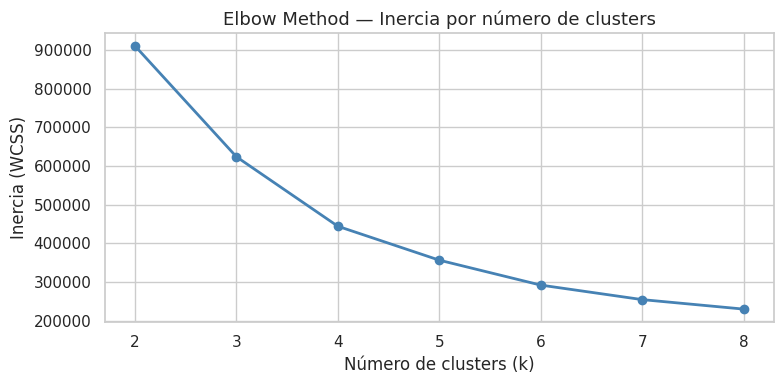

In [10]:
# ── ELBOW METHOD: ELEGIR EL k ÓPTIMO ─────────────────────────────────────────
# No elegimos k=3 de forma arbitraria. El Elbow Method entrena KMeans con
# distintos valores de k y mide la inercia (suma de distancias al centroide más cercano).
# La inercia baja conforme k sube, pero hay un punto de quiebre ("codo") donde
# agregar más clusters ya no mejora significativamente → ese es el k óptimo.

inertias = []         # Guardará la inercia de cada modelo
k_range = range(2, 9) # Probamos desde k=2 hasta k=8

for k in k_range:
    km = KMeans(k=k, seed=42, featuresCol="features", predictionCol="cluster")
    m = km.fit(youtube_ml)
    # trainingCost = inercia = suma de distancias cuadradas de cada punto a su centroide
    inertias.append(m.summary.trainingCost)

# Graficamos la curva de inercia
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(list(k_range), inertias, marker="o", color="steelblue", linewidth=2)
ax.set_title("Elbow Method — Inercia por número de clusters", fontsize=13)
ax.set_xlabel("Número de clusters (k)")
ax.set_ylabel("Inercia (WCSS)")
# Forzamos que el eje X solo muestre enteros (2, 3, 4... no 2.5, 3.5...)
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.tight_layout()
plt.show()

In [20]:
# ── MODELO KMEANS (k=3) ───────────────────────────────────────────────────────
# Usamos k=3 porque así lo decidimos y no porque el Elbow Method mostró el codo en ese punto.
# Conceptualmente tiene sentido: videos virales, videos populares y videos normales.

kmeans = KMeans(
    k=3,                      # Número de clusters (grupos) a crear
    seed=42,                  # Semilla para reproducibilidad: misma semilla = mismos resultados
    featuresCol="features",   # Columna con los features escalados (salida del StandardScaler)
    predictionCol="cluster"   # Nombre de la columna donde se guardará el cluster asignado
)

# .fit() entrena el modelo: encuentra los 3 centroides que minimizan la inercia
model = kmeans.fit(youtube_ml)

# .transform() asigna a cada video su cluster según el centroide más cercano
youtube_clusters = model.transform(youtube_ml)

# Revisamos los primeros resultados para verificar que el clustering funcionó
youtube_clusters.select("views", "likes", "comment_count", "cluster").show(5)

+-------+------+-------------+-------+
|  views| likes|comment_count|cluster|
+-------+------+-------------+-------+
| 748374| 57527|        15954|      0|
|2418783| 97185|        12703|      0|
|3191434|146033|         8181|      0|
| 343168| 10172|         2146|      0|
|2095731|132235|        17518|      0|
+-------+------+-------------+-------+
only showing top 5 rows


In [21]:
# ── EVALUACIÓN: SILHOUETTE SCORE ─────────────────────────────────────────────
# El Silhouette Score mide qué tan bien separados están los clusters.
# Rango: -1 a 1
#   Cerca de  1: los puntos están bien agrupados dentro de su cluster
#   Cerca de  0: los clusters se solapan
#   Cerca de -1: los puntos están asignados al cluster incorrecto
# Un score > 0.5 se considera bueno en datos reales.

evaluator = ClusteringEvaluator(
    featuresCol="features",    # Usamos las features escaladas para una evaluación justa
    predictionCol="cluster",
    metricName="silhouette"
)

silhouette = evaluator.evaluate(youtube_clusters)
print(f"Silhouette Score: {silhouette:.4f}")
print("(Rango: -1 a 1 | Más cercano a 1 = mejor separación de clusters)")

Silhouette Score: 0.9902
(Rango: -1 a 1 | Más cercano a 1 = mejor separación de clusters)


In [22]:
# ── CENTROIDES: EL "PERFIL TÍPICO" DE CADA CLUSTER ──────────────────────────
# Los centroides representan el video promedio de cada grupo en el espacio escalado.
# Imprimirlos nos ayuda a entender qué caracteriza a cada cluster.

centroids = model.clusterCenters()  # Devuelve lista de arrays numpy, uno por cluster

# Imprimimos en formato tabular para facilitar la comparación entre clusters
print(f"{'Cluster':<10} {'views':>15} {'likes':>15} {'dislikes':>12} {'comments':>12}")
print("-" * 60)
for i, c in enumerate(centroids):
    # c[0]=views, c[1]=likes, c[2]=dislikes, c[3]=comment_count (orden de 'features')
    print(f"  {i:<8} {c[0]:>15.0f} {c[1]:>15.0f} {c[2]:>12.0f} {c[3]:>12.0f}")

Cluster              views           likes     dislikes     comments
------------------------------------------------------------
  0                     -0              -0           -0           -0
  1                     12              14           63           37
  2                      9              10            3            7


In [23]:
# ── RESUMEN POR CLUSTER ───────────────────────────────────────────────────────
# Calculamos promedios reales (sin escalar) para interpretar los clusters
# en términos de negocio: cuántas vistas, likes, etc. tiene cada grupo en promedio

cluster_summary = youtube_clusters.groupBy("cluster").agg(
    F.avg("views").alias("avg_views"),
    F.avg("likes").alias("avg_likes"),
    F.avg("dislikes").alias("avg_dislikes"),
    F.avg("comment_count").alias("avg_comments"),
    F.avg("engagement").alias("avg_engagement"),
    F.count("*").alias("total_videos")  # Cuántos videos quedaron en cada cluster
).orderBy("cluster")  # Ordenamos por número de cluster para lectura consistente

cluster_summary.show()

+-------+-------------------+------------------+------------------+------------------+--------------------+------------+
|cluster|          avg_views|         avg_likes|      avg_dislikes|      avg_comments|      avg_engagement|total_videos|
+-------+-------------------+------------------+------------------+------------------+--------------------+------------+
|      0|  971204.7200684821| 28590.91008506768| 1435.016898507303|3066.5859852335348|0.043178370053519946|      373820|
|      1|8.832078633333333E7| 2294195.637681159|1425642.0869565217| 935640.6376811594|  0.0680551905130194|          69|
|      2|6.317053967820575E7|1655850.2345197464| 80197.75621647977|189303.77133105803|0.055366707227346525|        2051|
+-------+-------------------+------------------+------------------+------------------+--------------------+------------+



In [24]:
# ── ETIQUETAS SEMÁNTICAS Y DATASET PARA VISUALIZACIÓN ────────────────────────
# Convertimos a Pandas solo una vez (es la operación más costosa: trae datos del cluster Spark)
# Usamos muestra del 15% para que las gráficas no tengan millones de puntos solapados
# (más puntos no mejora la gráfica, solo la hace más lenta de renderizar)
cluster_pd = youtube_clusters.select(
    "views", "likes", "dislikes", "comment_count",
    "engagement", "engagement_positive", "cluster"
).sample(fraction=0.15, seed=42).toPandas()

# Determinamos dinámicamente qué cluster tiene mayor/menor engagement
# Así las etiquetas siempre son correctas aunque el modelo cambie en otra ejecución
cluster_mean  = cluster_pd.groupby("cluster")["engagement"].mean()
cluster_order = cluster_mean.sort_values().index.tolist()
# cluster_order[0] = cluster con menor engagement
# cluster_order[1] = engagement medio
# cluster_order[2] = cluster con mayor engagement

# Mapeamos número de cluster → etiqueta descriptiva
cluster_labels = {
    cluster_order[0]: "Bajo engagement",
    cluster_order[1]: "Engagement medio",
    cluster_order[2]: "Alto engagement"
}

# Colores con significado semántico: rojo=peligro/bajo, amarillo=alerta/medio, verde=bueno/alto
cluster_colors = {
    cluster_order[0]: "#e74c3c",   # Rojo → Bajo engagement
    cluster_order[1]: "#f39c12",   # Naranja/Amarillo → Engagement medio
    cluster_order[2]: "#27ae60"    # Verde → Alto engagement
}

# Agregamos las columnas de etiqueta y color al DataFrame de Pandas
cluster_pd["categoria"] = cluster_pd["cluster"].map(cluster_labels)
cluster_pd["color"]     = cluster_pd["cluster"].map(cluster_colors)

print("Distribución de clusters en la muestra:")
print(cluster_pd["categoria"].value_counts())

Distribución de clusters en la muestra:
categoria
Bajo engagement     56297
Engagement medio      284
Alto engagement         8
Name: count, dtype: int64


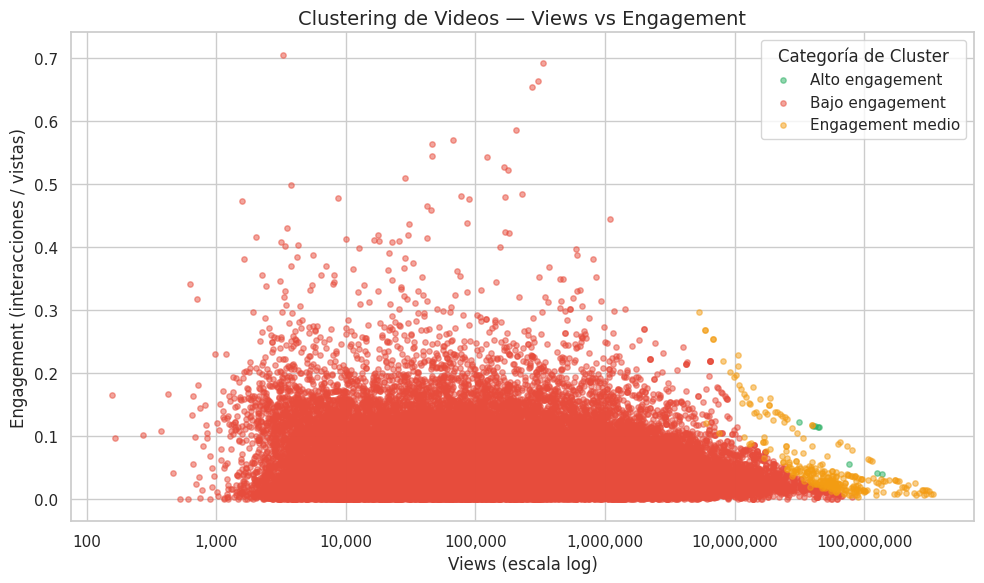

In [25]:
# ── SCATTER: VIEWS vs ENGAGEMENT ─────────────────────────────────────────────
# Esta gráfica es la más informativa: muestra cómo el engagement DECRECE
# conforme aumentan las vistas. Videos virales tienen más vistas pero
# proporcionalmente menos interacción por vista.

# Graficamos views (volumen) vs engagement (eficiencia) porque son los dos ejes
# conceptuales del análisis: QUÉ TAN GRANDE es el video vs QUÉ TAN ACTIVA es su audiencia.
#
# Esta gráfica revela el patrón más interesante del dataset:
# los videos más vistos tienden a tener MENOS engagement relativo,
# lo que sugiere que la viralidad masiva diluye la participación proporcional.


# Creamos paleta de colores a partir del DataFrame para usar los colores semánticos
palette = {row["categoria"]: row["color"]
           for _, row in cluster_pd[["categoria","color"]].drop_duplicates().iterrows()}

fig, ax = plt.subplots(figsize=(10, 6))

# Graficamos cada categoría por separado para controlar el color manualmente
for cat, grp in cluster_pd.groupby("categoria"):
    ax.scatter(
        grp["views"],
        grp["engagement"],
        label=cat,
        alpha=0.5,       # Transparencia para ver la densidad de puntos solapados
        s=15,            # Tamaño pequeño para no saturar la gráfica con tantos puntos
        color=palette[cat]
    )

# Escala logarítmica en X: las views van de miles a cientos de millones
# Sin log, el 99% de los puntos quedaría aplastado a la izquierda
ax.set_xscale("log")

ax.set_title("Clustering de Videos — Views vs Engagement", fontsize=14)
ax.set_xlabel("Views (escala log)")
ax.set_ylabel("Engagement (interacciones / vistas)")
ax.legend(title="Categoría de Cluster")

# Formateamos el eje X para mostrar números legibles en vez de notación científica
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.tight_layout()
plt.show()

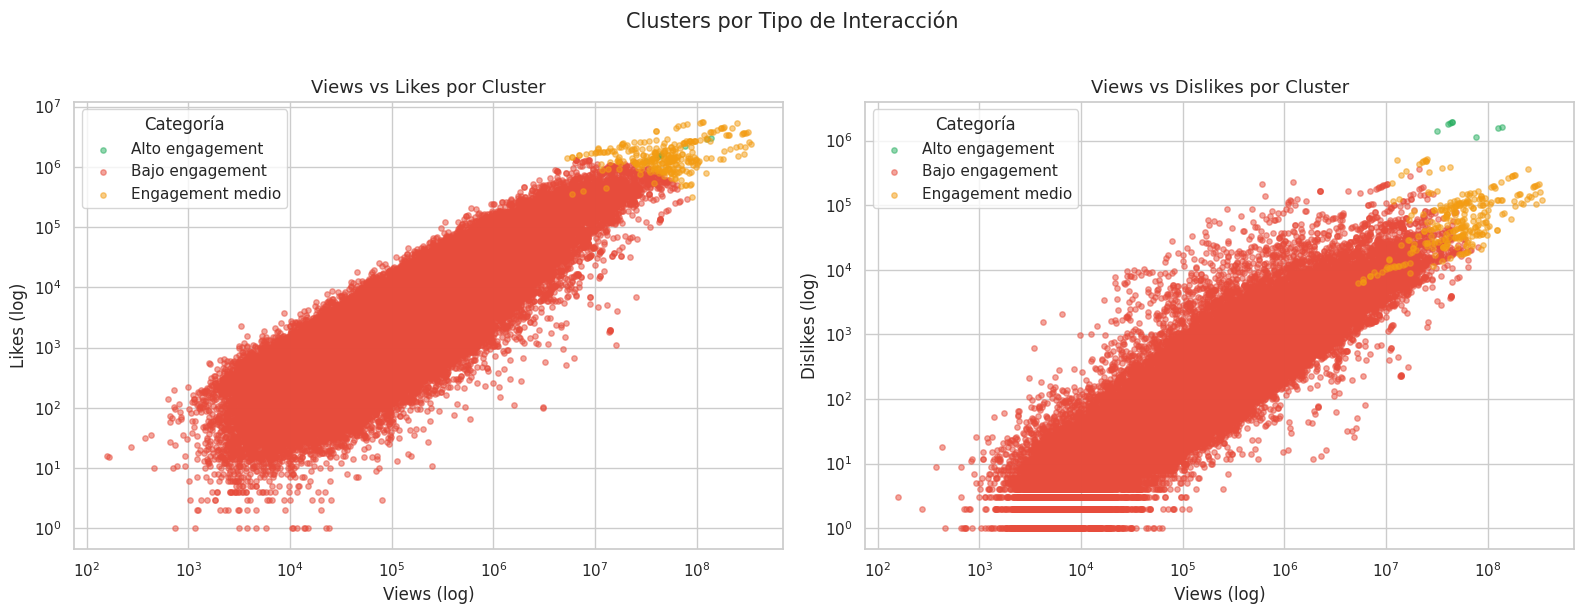

In [26]:
# ── COMPARATIVO: LIKES y DISLIKES EN SUBPLOTS ────────────────────────────────
# Ponemos ambas gráficas lado a lado para comparar directamente:
# ¿Los clusters se separan igual por likes que por dislikes?
# Esto revela si hay un patrón de controversia en algún cluster específico.

fig, axes = plt.subplots(1, 2, figsize=(16, 6))  # 1 fila, 2 columnas

# Iteramos sobre ambos ejes al mismo tiempo con zip()
# y_col es la variable del eje Y que cambia en cada subplot
for ax, y_col, title in zip(
    axes,
    ["likes", "dislikes"],
    ["Views vs Likes por Cluster", "Views vs Dislikes por Cluster"]
):
    for cat, grp in cluster_pd.groupby("categoria"):
        ax.scatter(
            grp["views"], grp[y_col],
            label=cat,
            alpha=0.5,
            s=15,
            color=palette[cat]
        )

    # Escala log en ambos ejes: tanto views como likes/dislikes
    # tienen distribución muy sesgada (ley de potencia)
    ax.set_xscale("log")
    ax.set_yscale("log")

    ax.set_title(title, fontsize=13)
    ax.set_xlabel("Views (log)")
    ax.set_ylabel(y_col.capitalize() + " (log)")
    ax.legend(title="Categoría")

plt.suptitle("Clusters por Tipo de Interacción", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

/tmp/ipykernel_603/3220856471.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


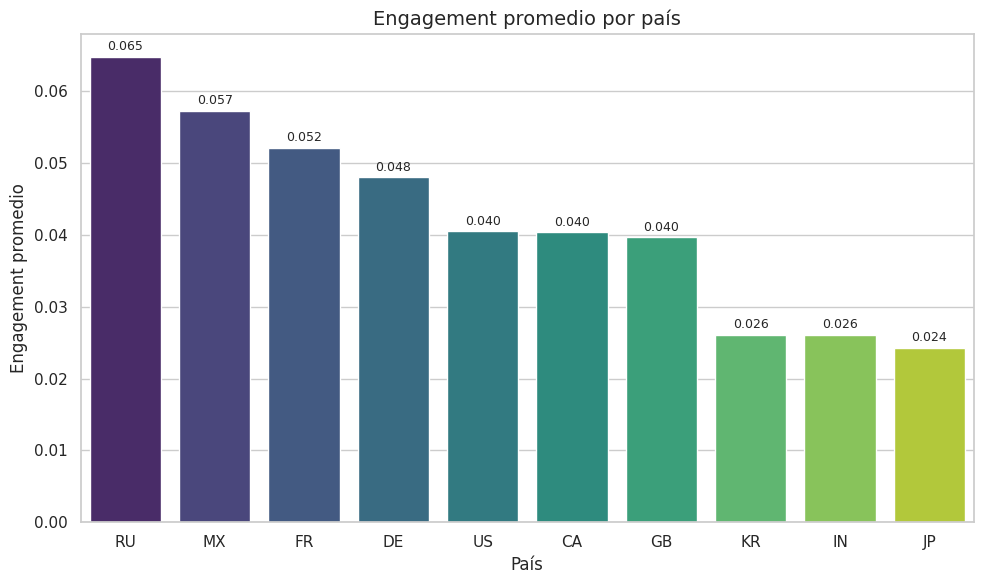

In [27]:
# ── MÉTRICAS AGREGADAS POR PAÍS ───────────────────────────────────────────────
# Agrupamos por país para ver si el comportamiento de la audiencia varía por región.
# Países con alto engagement promedio indican audiencias más activas relativamente.

region_metrics = youtube_ml.groupBy("country").agg(
    F.avg("views").alias("avg_views"),
    F.avg("likes").alias("avg_likes"),
    F.avg("comment_count").alias("avg_comments"),
    F.avg("engagement").alias("avg_engagement")
)

# Convertimos a Pandas y ordenamos de mayor a menor engagement para el barplot
region_pd = region_metrics.toPandas().sort_values("avg_engagement", ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))

# Barplot ordenado de mayor a menor engagement
# order= fuerza a seaborn a respetar el orden ya establecido en region_pd
sns.barplot(
    data=region_pd,
    x="country",
    y="avg_engagement",
    palette="viridis",            # Gradiente de colores para distinguir niveles
    order=region_pd["country"],   # Orden descendente por engagement
    ax=ax
)

# Agregamos etiquetas de valor sobre cada barra para facilitar la lectura exacta
# sin necesidad de que el lector estime el valor desde el eje Y
for bar, val in zip(ax.patches, region_pd["avg_engagement"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,  # Centro horizontal de la barra
        bar.get_height() + 0.0005,           # Ligeramente arriba del tope de la barra
        f"{val:.3f}",                        # 3 decimales para precisión
        ha="center", va="bottom", fontsize=9
    )

ax.set_title("Engagement promedio por país", fontsize=14)
ax.set_xlabel("País")
ax.set_ylabel("Engagement promedio")
plt.tight_layout()
plt.show()

/tmp/ipykernel_603/3073073148.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


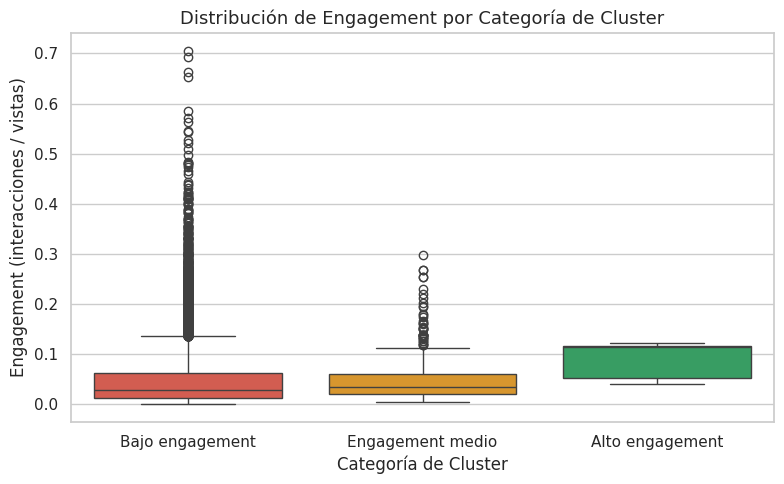

In [28]:
# ── BOXPLOT FINAL: ENGAGEMENT POR CATEGORÍA DE CLUSTER ──────────────────────
# Esta gráfica sirve como VALIDACIÓN del clustering:
# Si las cajas no se solapan entre categorías, significa que el modelo logró
# separar bien los niveles de engagement. Es el cierre del análisis.

fig, ax = plt.subplots(figsize=(8, 5))

# Definimos el orden manual para que siempre aparezca: Bajo → Medio → Alto
order_cats = ["Bajo engagement", "Engagement medio", "Alto engagement"]

# Reutilizamos los colores semánticos definidos en la celda 14
palette_cats = {
    "Bajo engagement":  "#e74c3c",
    "Engagement medio": "#f39c12",
    "Alto engagement":  "#27ae60"
}

sns.boxplot(
    data=cluster_pd,
    x="categoria",
    y="engagement",
    order=order_cats,        # Orden lógico de menor a mayor
    palette=palette_cats,    # Colores semánticos consistentes con el resto del notebook
    ax=ax
)

ax.set_title("Distribución de Engagement por Categoría de Cluster", fontsize=13)
ax.set_xlabel("Categoría de Cluster")
ax.set_ylabel("Engagement (interacciones / vistas)")
plt.tight_layout()
plt.show()